In [329]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [247]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [249]:
X_train = X_train / 255
X_test = X_test / 255

In [251]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [421]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(392, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer= 'adam',
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

model.fit(X_train, y_train, epochs=40)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8971 - loss: 0.3586
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9742 - loss: 0.0881
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9834 - loss: 0.0519
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9890 - loss: 0.0359
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9924 - loss: 0.0249
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9932 - loss: 0.0215
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9956 - loss: 0.0144
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9959 - loss: 0.0130
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9954 - loss: 0.0128
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0078
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9978 - loss: 0.0074
Epoch 12/40
1875/1875 ━━━━━

In [397]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9756 - loss: 0.0770


[0.06685890257358551, 0.978600025177002]

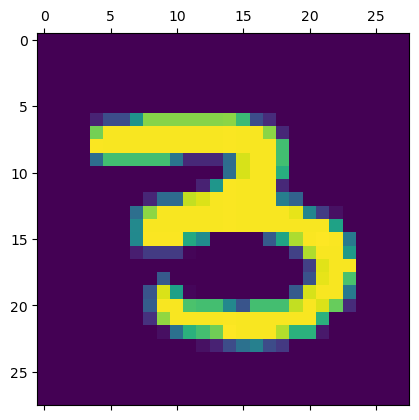

In [404]:
plt.matshow(X_test[51])

In [409]:
y_predicted = model.predict(X_test)
print(y_predicted[51])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.7625520e-05 1.1531761e-04 9.0346681e-03 9.9995673e-01 1.8572963e-04
 7.2691940e-02 1.0806348e-06 2.2640694e-02 1.4389369e-01 2.0444947e-03]


In [411]:
np.argmax(y_predicted[51])

3

In [413]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[7, 2, 1, 0, 4]

In [415]:
cm = tf.math.confusion_matrix(labels=y_test, predictions= y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 971,    0,    1,    0,    0,    2,    3,    1,    2,    0],
       [   0, 1129,    2,    1,    0,    0,    2,    0,    1,    0],
       [   5,    2, 1002,    3,    2,    0,    3,    4,   10,    1],
       [   1,    0,    4,  982,    0,   12,    0,    4,    4,    3],
       [   2,    0,    2,    0,  968,    0,    2,    0,    1,    7],
       [   2,    0,    0,    1,    1,  882,    3,    0,    1,    2],
       [   4,    2,    1,    1,    6,    4,  940,    0,    0,    0],
       [   2,    1,    8,    4,    0,    1,    0,  998,    5,    9],
       [   5,    0,    1,    2,    4,    4,    2,    2,  950,    4],
       [   0,    2,    0,    0,    7,    7,    0,    2,    1,  990]])>

Text(95.72222222222221, 0.5, 'Truth')

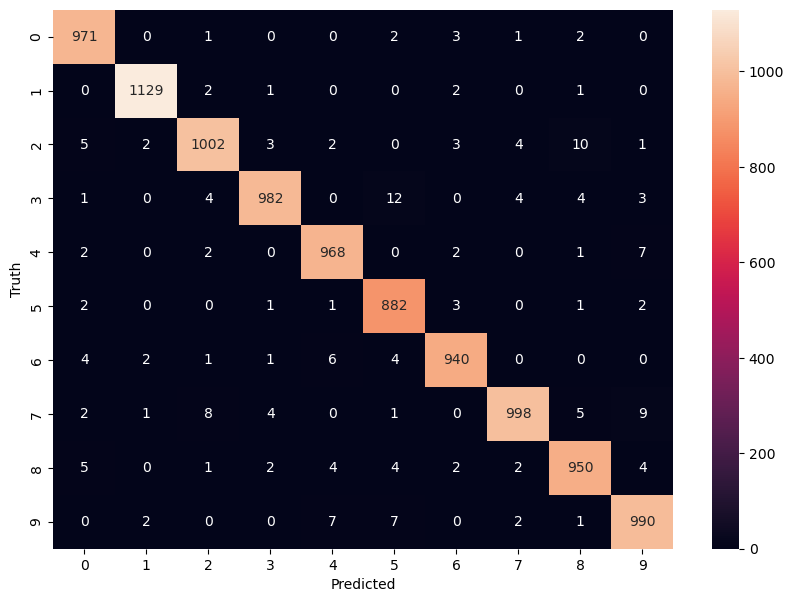

In [417]:
plt.figure(figsize = (10, 7))
sn.heatmap(cm, annot= True, fmt= 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')